Test with tf savedmodel format model file

In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 21.2/107.7 GB disk)


In [ ]:
import cv2, os
import numpy as np
from PIL import Image
import tensorflow as tf
from ultralytics import YOLO
import matplotlib.pyplot as plt

Loading required models

In [ ]:
fish_model = YOLO('/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/fish (1).pt')
cuts_damages_model = YOLO("/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/cut-seg.pt")
savedmodel_path = "/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/sardine_model_20epochs_k_gpu"
loaded = tf.saved_model.load(savedmodel_path)
infer = loaded.signatures["serving_default"]
softness_model = infer

In [ ]:
def yolo_results(img_path, model, imgsz=640, conf=0.75, iou=0.7):
    results = model(img_path, imgsz=imgsz, conf=conf, iou=iou, verbose=False)
    return results

cuts and damages utils

In [ ]:
def process_image(image, size=(640, 640)): # for eye model
    h, w = image.shape[:2]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)

    resized_image = cv2.resize(image, (new_w, new_h))

    pad_h = (size[1] - new_h) // 2
    pad_w = (size[0] - new_w) // 2
    padded_image = cv2.copyMakeBorder(
        resized_image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    padded_image = cv2.resize(padded_image, (640,640))
    return np.asarray(padded_image)

def cuts_damages(seg_img):
    image = process_image(seg_img)
    image = image[:,:,::-1]
    results = yolo_results(image, cuts_damages_model, conf=0.5, iou=0.7)
    cuts_detected = len(results[0].boxes.cls)
    if cuts_detected == 0:
        return None
    else:
        return True

In [ ]:
def softness_model_predict(seg_img, model):
    img = cv2.resize(seg_img, (224, 224))
    img_array = tf.keras.applications.densenet.preprocess_input(img)
    img_array = tf.expand_dims(img_array, axis=0)
    labeling = infer(img_array)
    pred = 'Good' if labeling['output_0'].numpy()[0][0] >= 0.5 else 'Bad'
    return pred

Drawing bboxes, masks and labels

In [ ]:
def add_text(img, text):
    font = cv2.FONT_HERSHEY_SIMPLEX
    fontScale = 3
    color = (0, 0, 0)
    thickness = 2

    # Using cv2.putText() method
    out_img = cv2.putText(img, text, (10, 30), font, fontScale, color, thickness, cv2.LINE_AA)
    return out_img

def get_segmented_img(pred, white_background=False, index=0):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    mask = masks[index]
    mask_points = mask.astype(int)
    binary_mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(binary_mask, [mask_points], 255)
    masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
    x, y, w, h = cv2.boundingRect(mask_points)
    x1, y1, x2, y2 = (x, y, x+w, y+h)
    box = [x1, y1, x2, y2]
    segment_image = np.zeros((height, width, 3), dtype=np.uint8)
    segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
    segment_image = segment_image[y:y+h, x:x+w]
    # white_background = False
    if white_background:
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [255, 255, 255]
    return segment_image, mask, box

def get_colors(pred_class):
    if pred_class == 'Bad':
        color = (0, 0, 235)
    else:
        color = (0, 235, 0)
    return color

def draw_annotated_boxes_v2(img, box, color, text):
    img_height, img_width = img.shape[:2]

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.8 # Slightly reduced font scale for better fit
    font_color = (255, 255, 255)  # White color
    font_thickness = 2
    padding = 2 # Padding around text and background

    # Get the size of the text
    (text_width, text_height), baseline = cv2.getTextSize(
        text, font, font_scale, font_thickness
    )

    # Attempt to place text above the bounding box
    text_x = box[0]
    text_y = box[1] - padding # This is the bottom-most point of the text (baseline)

    # Calculate background rectangle coordinates
    bg_rect_start_x = text_x - padding
    bg_rect_start_y = text_y - text_height - padding # Top of the background
    bg_rect_end_x = text_x + text_width + padding
    bg_rect_end_y = text_y + baseline + padding # Bottom of the background

    # Adjust position if it goes above the image top boundary
    if bg_rect_start_y < 0:
        # Place text inside the bounding box, at the top
        text_y = box[1] + text_height + padding  # New baseline inside the box
        bg_rect_start_y = box[1] # Background starts at the top of the bounding box
        bg_rect_end_y = text_y + baseline + padding # Recalculate end_y

    # Ensure coordinates are within image bounds
    bg_rect_start_x = max(0, bg_rect_start_x)
    bg_rect_start_y = max(0, bg_rect_start_y)
    bg_rect_end_x = min(img_width, bg_rect_end_x)
    bg_rect_end_y = min(img_height, bg_rect_end_y)

    # Draw the main bounding box
    cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), color, 5)

    # Draw the background rectangle for the text
    cv2.rectangle(img, (bg_rect_start_x, bg_rect_start_y),
                  (bg_rect_end_x, bg_rect_end_y), color, -1)

    # Put the text on the image using the adjusted baseline y-coordinate
    out_img = cv2.putText(img, text, (text_x, text_y),
                          font, font_scale, font_color, font_thickness, cv2.LINE_AA)
    return out_img

def fill_mask_v2(img, mask, color):
    height, width = img.shape[0], img.shape[1]
    binary_mask = np.zeros((height, width), dtype=np.uint8)
    mask = mask.astype(np.int32)
    cv2.fillPoly(binary_mask, [mask], 255)

    masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
    masked_img[binary_mask == 255] = color
    transparency = 0.6
    masked_img = cv2.addWeighted(img, 1.0, masked_img, transparency, 0)
    return masked_img

def draw_bbox_masks_labels_v2(img, mask, box, text, color):
    masked_img = fill_mask_v2(img, mask, color)
    out_img = draw_annotated_boxes_v2(masked_img, box, color, text)
    return out_img

getting final predictions for each image

In [ ]:
def get_result_img_v2(results):
    obj_detected = len(results[0].boxes.cls)
    print(f'Number of objects detected: {obj_detected}')
    if obj_detected == 0:
        output_img = add_text(results[0].orig_img.copy(), 'No fish detected')
        return output_img
    else:
        output_img = results[0].orig_img.copy() # Make a copy to avoid modifying original
        for i in range(obj_detected):
            # Get segmented image for cuts_damages (with white background)
            segmented_img_cuts, mask_cuts, bbox_cuts = get_segmented_img(results[0], True, i)
            cuts = cuts_damages(segmented_img_cuts)

            if (cuts is None) or (cuts is False):
                # If no cuts, then predict softness. Get segmented image for softness (with black background)
                segmented_img_softness, mask_softness, bbox_softness = get_segmented_img(results[0], False, i)
                pred = softness_model_predict(segmented_img_softness, softness_model)
                color = get_colors(pred)
                text = f'{pred}: Soft'
                if pred == 'Good': text = f'{pred}'
                print(text)
                output_img = draw_bbox_masks_labels_v2(output_img, mask_softness,
                                                    bbox_softness, text, color)
            else:
                pred = 'Bad'
                color = get_colors(pred)
                text = f'{pred}: Cuts'
                print(text)
                output_img = draw_bbox_masks_labels_v2(output_img, mask_cuts, bbox_cuts,
                                                    text, color)
    return output_img

### Running with the new functions

Number of objects detected: 3
Bad: Soft
Bad: Soft
Bad: Soft


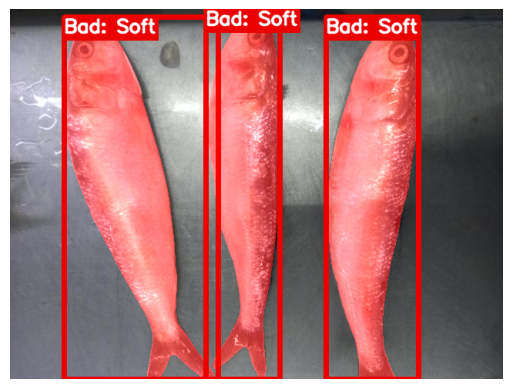

In [ ]:
img_path = "/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/2023-11-23_09_49_41_(2195)_sardine_input.jpeg"
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img_v2 = get_result_img_v2(results)
rgb_img_v2 = cv2.cvtColor(output_img_v2, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img_v2);
plt.axis('off');

Number of objects detected: 2
Bad: Cuts
Bad: Cuts


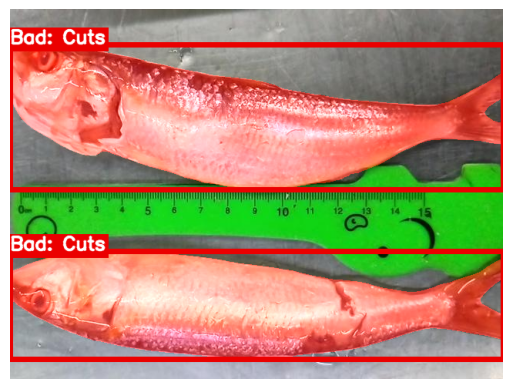

In [ ]:
img_path = "/content/drive/MyDrive/Sowmya /input/2024-12-03/sardine/Bad/2024-12-03_10_14_57_(17680)_sardine_input.jpeg"
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img_v2 = get_result_img_v2(results)
rgb_img_v2 = cv2.cvtColor(output_img_v2, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img_v2);
plt.axis('off');

In [ ]:
import pandas as pd
def get_results_with_reason(results):
    obj_detected = len(results[0].boxes.cls)
    if obj_detected == 0:
        return 'No fish detected', 'No fish detected'
    else:
        preds=[]
        reasons=[]
        output_img = results[0].orig_img.copy() # Make a copy to avoid modifying original
        for i in range(obj_detected):
            # Get segmented image for cuts_damages (with white background)
            segmented_img_cuts, mask_cuts, bbox_cuts = get_segmented_img(results[0], True, i)
            cuts = cuts_damages(segmented_img_cuts)

            if (cuts is None) or (cuts is False):
                # If no cuts, then predict softness. Get segmented image for softness (with black background)
                segmented_img_softness, mask_softness, bbox_softness = get_segmented_img(results[0], False, i)
                pred = softness_model_predict(segmented_img_softness, softness_model)
                reason = 'Soft'
                if pred == 'Good': reason = 'Good'
            else:
                pred = 'Bad'
                reason = 'Cuts'
            preds.append(pred)
            reasons.append(reason)
        return preds, reasons

from tqdm import tqdm
def get_df_for_folder(single_folder_path):
    data = []
    for filename in tqdm(os.listdir(single_folder_path)):
        img_path = os.path.join(single_folder_path, filename)
        if not os.path.isfile(img_path): continue
        results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
        pred, reason = get_results_with_reason(results)
        filenames=[filename]*len(pred)
        data.append([filenames, pred, reason])

    # Create lists for each column
    filename_list = []
    pred_list = []
    reason_list = []

    # Iterate through the nested list and extract values
    for sublist in data:
        filename_list.extend(sublist[0])
        pred_list.extend(sublist[1])
        reason_list.extend(sublist[2])

    new_df = pd.DataFrame({'filename': filename_list,
                           'pred': pred_list,
                           'reason': reason_list})
    return new_df

def test_multiple_folders(folder_path):
    dfs=[]
    for date in os.listdir(folder_path):
        species_folder_path = os.path.join(folder_path, date, 'sardine')
        if not os.path.isdir(species_folder_path): continue
        for folder in os.listdir(species_folder_path):
            single_folder_path = os.path.join(species_folder_path, folder)
            new_df = get_df_for_folder(single_folder_path)
            new_df['actual'] = folder
            # new_df['Date'] = new_df['filename'].str[:10]
            dfs.append(new_df)
    return pd.concat(dfs)

folder_path = "/content/drive/MyDrive/Sowmya /input"
ndf = test_multiple_folders(folder_path)
ndf

100%|██████████| 54/54 [04:31<00:00,  5.03s/it]


,filename,pred,reason,actual
0,2025-01-21_10_16_46_(18770)_sardine_input.jpeg,Good,Good,Good
1,2025-01-21_10_16_46_(18770)_sardine_input.jpeg,Good,Good,Good
2,2025-01-21_10_22_30_(18795)_sardine_input.jpeg,Good,Good,Good
3,2025-01-21_10_22_30_(18795)_sardine_input.jpeg,Good,Good,Good
4,2025-01-21_10_18_01_(18776)_sardine_input.jpeg,Good,Good,Good
...,...,...,...,...
103,2024-12-26_09_29_11_(18171)_sardine_input.jpeg,Good,Good,Good
104,2024-12-26_09_35_47_(18207)_sardine_input.jpeg,Good,Good,Good
105,2024-12-26_09_35_47_(18207)_sardine_input.jpeg,Good,Good,Good
106,2024-12-26_09_31_08_(18177)_sardine_input.jpeg,Good,Good,Good


In [ ]:
ndf.to_csv("/content/drive/MyDrive/Sowmya /input/local_test_results.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "red")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

Classification Report:

              precision    recall  f1-score   support

         Bad       0.66      0.66      0.66       476
        Good       0.80      0.81      0.81       835

    accuracy                           0.75      1311
   macro avg       0.73      0.73      0.73      1311
weighted avg       0.75      0.75      0.75      1311

Confusion matrix, without normalization


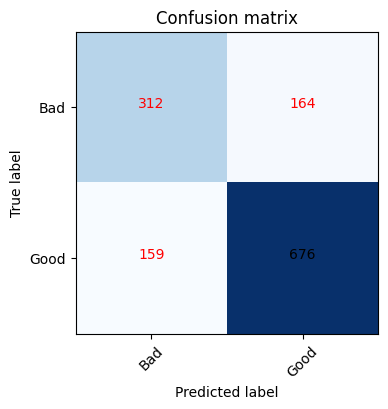

In [ ]:
new_df = ndf
# new_df = temp
predictions = new_df['pred'].values
true_labels = new_df['actual'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])